# uPEG Dashboard Data Analysis


## Step 1 价格与池库存的同期关系（双边价值）

数据：`output-upeg-may-2026/`，日频快照 2026-05-01 至 2026-05-31。

库存是池的**双边 USD 价值**（两侧代币分别计价后相加），不是 AMM 单边数量，也不是只把 uPEG 乘价格：

`bilateral_usd = uPEG数量 × uPEG美元价 + 报价代币数量 × 报价代币美元价`

- uPEG 数量：该 `snapshot_block` 上池合约 `balanceOf(uPEG)`
- 报价代币数量：同一区块上 WETH/USDC 的 `balanceOf`
- uPEG 美元价：该池当日 swap 隐含价
- 报价美元价：该池当日最后一笔 swap 的 `amount_usd / quote_amount`；缺测则按同一报价资产向前填充

V4 共享 PoolManager 不在 timeline 中。目标余额为 1 wei 的灰尘池不进入相关计算。


In [29]:
from __future__ import annotations

import json
import os
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from web3 import Web3

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd().resolve()
if not (ROOT / "output-upeg-may-2026").exists():
    ROOT = ROOT.parent
load_dotenv(ROOT / ".env")
sys.path.insert(0, str(ROOT))

from src.client import get_contract, get_web3

OUT = ROOT / "output-upeg-may-2026"
CACHE = ROOT / "notebooks" / "_cache"
CACHE.mkdir(parents=True, exist_ok=True)
RESERVE_CACHE = CACHE / "upeg-may-2026-quote-reserves.json"
QUOTE_USD_CACHE = CACHE / "upeg-may-2026-quote-usd.json"
PANEL_CACHE = CACHE / "upeg-may-2026-bilateral-panel.csv"

TARGET = "0x44b28991b167582f18ba0259e0173176ca125505"
QUOTE_DECIMALS = {
    "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2": (18, "WETH"),
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": (6, "USDC"),
}
POOL_LABEL = {
    "0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775": "V3 uPEG/WETH 1%",
    "0x21ff5cf76f562c6fb3871b59133a9e214ebc0078": "V2 uPEG/WETH",
    "0x84a69fcd071d5c36ef9ca3a31b1ff3aefb314230": "V3 uPEG/USDC 1%",
    "0x7059a9f16dd2405aef3dd4f70a89127ce577a890": "V3 uPEG/USDC 0.3%",
}
DUST_POOLS = {"0x84a69fcd071d5c36ef9ca3a31b1ff3aefb314230"}  # 1 wei uPEG + 2 raw USDC


def pearson(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3:
        return np.nan
    x = x - x.mean()
    y = y - y.mean()
    den = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / den) if den else np.nan


def spearman(x, y) -> float:
    return pearson(pd.Series(x).rank(), pd.Series(y).rank())


def dlog(values) -> pd.Series:
    return np.log(pd.Series(values, dtype=float)).diff()


timeline = json.loads((OUT / "tvl_timeline.json").read_text())
pools = {
    p["pool_address"].lower(): p
    for p in json.loads((OUT / "verified_pools.json").read_text())
}
print(f"timeline rows={len(timeline)} pools={sorted({r['pool_address'].lower() for r in timeline})}")


timeline rows=90 pools=['0x21ff5cf76f562c6fb3871b59133a9e214ebc0078', '0x7059a9f16dd2405aef3dd4f70a89127ce577a890', '0x84a69fcd071d5c36ef9ca3a31b1ff3aefb314230', '0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775']


In [30]:
jobs = []
seen = set()
for row in timeline:
    pa = row["pool_address"].lower()
    snap = int(row["snapshot_block"])
    key = (pa, snap)
    if key in seen:
        continue
    seen.add(key)
    meta = pools[pa]
    t0 = meta["token0"].lower()
    quote = meta["token1"].lower() if t0 == TARGET else t0
    jobs.append(
        {
            "pool_address": pa,
            "snapshot_block": snap,
            "custody": (meta.get("custody_address") or meta["pool_address"]).lower(),
            "quote_token": quote,
            "quote_decimals": QUOTE_DECIMALS[quote][0],
            "version": meta.get("version"),
        }
    )

cached = json.loads(RESERVE_CACHE.read_text()) if RESERVE_CACHE.exists() else []
have = {
    (r["pool_address"], int(r["snapshot_block"]))
    for r in cached
    if r.get("quote_balance_raw") is not None
}
pending = [j for j in jobs if (j["pool_address"], j["snapshot_block"]) not in have]
print(f"quote-reserve jobs={len(jobs)} cached={len(have)} pending={len(pending)}")

if pending:
    w3 = get_web3()
    contracts: dict[str, object] = {}

    def fetch(job: dict) -> dict:
        token = job["quote_token"]
        if token not in contracts:
            contracts[token] = get_contract(
                w3, Web3.to_checksum_address(token), "erc20"
            )
        contract = contracts[token]
        bal = int(
            contract.functions.balanceOf(
                Web3.to_checksum_address(job["custody"])
            ).call(block_identifier=job["snapshot_block"])
        )
        out = dict(job)
        out["quote_balance_raw"] = str(bal)
        return out

    with ThreadPoolExecutor(max_workers=8) as ex:
        for fut in as_completed([ex.submit(fetch, j) for j in pending]):
            cached.append(fut.result())
    RESERVE_CACHE.write_text(json.dumps(cached, indent=2))

quote_reserves = {
    (r["pool_address"], int(r["snapshot_block"])): r for r in cached
}
assert all(
    (j["pool_address"], j["snapshot_block"]) in quote_reserves for j in jobs
), "missing quote reserve snapshots"
print("quote reserves ready", len(quote_reserves))


quote-reserve jobs=90 cached=90 pending=0
quote reserves ready 90


In [31]:
pool_set = {r["pool_address"].lower() for r in timeline}
if QUOTE_USD_CACHE.exists():
    quote_usd_rows = json.loads(QUOTE_USD_CACHE.read_text())
else:
    swaps = json.loads((OUT / "swaps.json").read_text())
    last: dict[tuple[str, int], tuple[int, int, float, str, str]] = {}
    for swap in swaps:
        pa = (swap.get("pool_address") or "").lower()
        if pa not in pool_set:
            continue
        usd = swap.get("amount_usd")
        if not usd or float(usd) <= 0:
            continue
        t0 = (swap.get("token0_address") or "").lower()
        t1 = (swap.get("token1_address") or "").lower()
        if t0 == TARGET:
            quote, raw = t1, swap.get("token1_amount")
        elif t1 == TARGET:
            quote, raw = t0, swap.get("token0_amount")
        else:
            continue
        meta = QUOTE_DECIMALS.get(quote)
        if not meta:
            continue
        quote_tokens = abs(int(raw or 0)) / (10 ** meta[0])
        if quote_tokens <= 0:
            continue
        ts = int(swap.get("block_timestamp") or 0)
        if ts <= 0:
            continue
        day = (ts // 86400) * 86400
        bn = int(swap.get("block_number") or 0)
        li = int(swap.get("log_index") or 0)
        quote_usd = float(usd) / quote_tokens
        key = (pa, day)
        prev = last.get(key)
        if prev is None or (bn, li) >= (prev[0], prev[1]):
            last[key] = (bn, li, quote_usd, meta[1], quote)
    quote_usd_rows = [
        {
            "pool_address": pa,
            "day_ts": day,
            "quote_usd": quote_usd,
            "quote_symbol": sym,
            "quote_token": tok,
            "source_block": bn,
            "source_log_index": li,
        }
        for (pa, day), (bn, li, quote_usd, sym, tok) in last.items()
    ]
    QUOTE_USD_CACHE.write_text(json.dumps(quote_usd_rows, indent=2))

quote_usd_map = {
    (r["pool_address"], int(r["day_ts"])): r for r in quote_usd_rows
}
quote_usd_by_token: dict[str, list[dict]] = {}
for row in sorted(quote_usd_rows, key=lambda item: item["day_ts"]):
    quote_usd_by_token.setdefault(row["quote_token"], []).append(row)
print(f"quote-usd pool-days={len(quote_usd_rows)}")


def quote_usd_for(token: str, day_ts: int, pool: str) -> tuple[float | None, str | None]:
    direct = quote_usd_map.get((pool, day_ts))
    if direct is not None:
        return float(direct["quote_usd"]), "pool_swap"
    earlier = [x for x in quote_usd_by_token.get(token, []) if x["day_ts"] <= day_ts]
    if earlier:
        return float(earlier[-1]["quote_usd"]), "token_carry"
    if token == "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48":
        return 1.0, "usdc_one"
    return None, None


quote-usd pool-days=59


In [32]:
rows = []
for row in timeline:
    pa = row["pool_address"].lower()
    snap = int(row["snapshot_block"])
    meta = pools[pa]
    t0 = meta["token0"].lower()
    quote = meta["token1"].lower() if t0 == TARGET else t0
    qdec, qsym = QUOTE_DECIMALS[quote]
    qrow = quote_reserves[(pa, snap)]
    target_tokens = int(row["tvl_in_token"]) / 1e18
    quote_tokens = int(qrow["quote_balance_raw"]) / (10 ** qdec)
    price_usd = float(row["price_usd"])
    q_usd, q_src = quote_usd_for(quote, int(row["block_timestamp"]), pa)
    target_usd = target_tokens * price_usd
    quote_usd_value = quote_tokens * q_usd if q_usd is not None else None
    bilateral_usd = (
        target_usd + quote_usd_value if quote_usd_value is not None else None
    )
    rows.append(
        {
            "pool": POOL_LABEL[pa],
            "pool_address": pa,
            "day": datetime.fromtimestamp(
                int(row["block_timestamp"]), tz=timezone.utc
            ).date().isoformat(),
            "ts": int(row["block_timestamp"]),
            "snapshot_block": snap,
            "version": row["version"],
            "quote_symbol": qsym,
            "price_usd": price_usd,
            "target_tokens": target_tokens,
            "quote_tokens": quote_tokens,
            "target_usd": target_usd,
            "quote_usd": quote_usd_value,
            "bilateral_usd": bilateral_usd,
            "quote_usd_px": q_usd,
            "quote_px_src": q_src,
            "side_ratio": (
                quote_usd_value / target_usd
                if quote_usd_value is not None and target_usd > 0
                else None
            ),
        }
    )

panel = pd.DataFrame(rows).sort_values(["pool", "ts"]).reset_index(drop=True)
panel["usable"] = ~panel["pool_address"].isin(DUST_POOLS)
panel.to_csv(PANEL_CACHE, index=False)

usable = panel.loc[panel["usable"]].copy()
print("excluded dust pool-days", int((~panel["usable"]).sum()))
display(
    usable.groupby("pool")[["target_usd", "quote_usd", "bilateral_usd", "side_ratio"]]
    .agg(["count", "median", "min", "max"])
    .round(2)
)
display(usable.head(8))


excluded dust pool-days 26


target_usd                               quote_usd  \
                       count    median      min        max     count   
pool                                                                   
V2 uPEG/WETH              27      1.99     0.48    7329.12        27   
V3 uPEG/USDC 0.3%          6   5755.11  4943.01    7221.42         6   
V3 uPEG/WETH 1%           31  23681.09  9901.82  105886.58        31   

                                                 bilateral_usd            \
                     median       min        max         count    median   
pool                                                                       
V2 uPEG/WETH           1.97      1.33    7334.16            27      3.77   
V3 uPEG/USDC 0.3%   5137.84   1811.94    5863.23             6  10547.17   
V3 uPEG/WETH 1%    21459.49  12208.06  179018.02            31  45140.58   

                                       side_ratio                     
                        min        max      count median   min   max  
pool                                                                  
V2 uPEG/WETH           1.98   14663.28         27   0.99  0.08  3.11  
V3 uPEG/USDC 0.3%   9033.36   11100.71          6   0.89  0.25  1.16  
V3 uPEG/WETH 1%    27273.58  247429.70         31   0.93  0.55  2.62

,pool,pool_address,day,ts,snapshot_block,version,quote_symbol,price_usd,target_tokens,quote_tokens,target_usd,quote_usd,bilateral_usd,quote_usd_px,quote_px_src,side_ratio,usable
0,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-05,1777939200,25032251,v2,WETH,1480.503892,0.413843,0.237754,612.696380,561.179135,1173.875515,2360.34,pool_swap,0.915917,True
1,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-06,1778025600,25039426,v2,WETH,1120.374565,0.005575,0.002658,6.246252,6.277103,12.523355,2361.44,pool_swap,1.004939,True
2,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-07,1778112000,25046605,v2,WETH,880.720173,0.006630,0.002295,5.839477,5.257708,11.097185,2290.57,pool_swap,0.900373,True
3,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-08,1778198400,25053792,v2,WETH,2639.778388,0.006255,0.002462,16.512833,5.639238,22.152071,2290.84,pool_swap,0.341506,True
4,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-09,1778284800,25060963,v2,WETH,1294.070895,0.068240,0.037026,88.307938,86.331550,174.639488,2331.62,pool_swap,0.977619,True
5,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-10,1778371200,25068131,v2,WETH,1127.813902,0.575847,0.272845,649.448302,647.229022,1296.677323,2372.15,pool_swap,0.996583,True
6,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-11,1778457600,25075302,v2,WETH,920.321683,0.632208,0.247105,581.834690,578.432907,1160.267597,2340.84,pool_swap,0.994153,True
7,V2 uPEG/WETH,0x21ff5cf76f562c6fb3871b59133a9e214ebc0078,2026-05-12,1778544000,25082470,v2,WETH,913.392318,0.001928,0.000757,1.760934,1.743447,3.504381,2303.83,pool_swap,0.990069,True


In [33]:
records = []
for pool_name, group in usable.groupby("pool"):
    group = group.dropna(subset=["price_usd", "bilateral_usd"]).sort_values("ts")
    n = len(group)
    dp = dlog(group["price_usd"])
    di = dlog(group["bilateral_usd"])
    mask = dp.notna() & di.notna()
    records.append(
        {
            "pool": pool_name,
            "N": n,
            "dN": int(mask.sum()),
            "pearson_level": pearson(group["price_usd"], group["bilateral_usd"]),
            "spearman_level": spearman(group["price_usd"], group["bilateral_usd"]),
            "pearson_dlog": pearson(dp[mask], di[mask]),
            "spearman_dlog": spearman(dp[mask], di[mask]),
            "median_side_ratio": float(group["side_ratio"].median()),
        }
    )

corr = pd.DataFrame(records)
display(corr.round(4))


,pool,N,dN,pearson_level,spearman_level,pearson_dlog,spearman_dlog,median_side_ratio
0,V2 uPEG/WETH,27,26,-0.0447,0.7879,0.1533,0.4973,0.9901
1,V3 uPEG/USDC 0.3%,6,5,0.9079,0.7143,0.9832,0.9000,0.8936
2,V3 uPEG/WETH 1%,31,30,0.6981,0.7927,0.5063,0.4358,0.9346


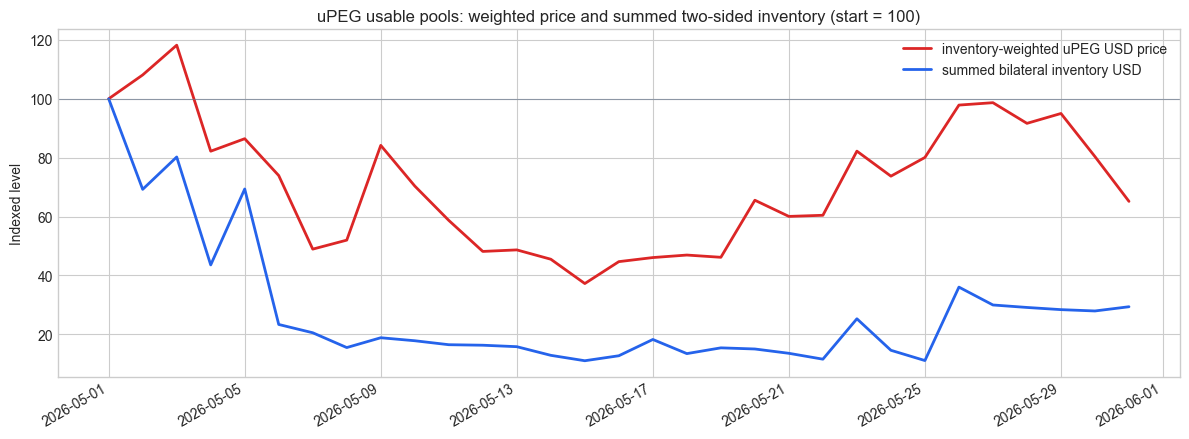

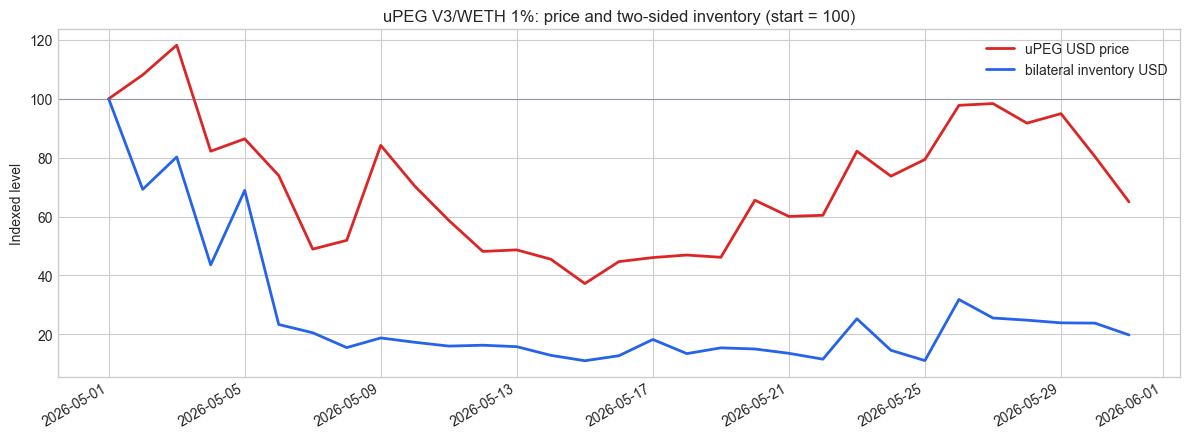

In [27]:
def indexed_line_chart(dates, series_map, title):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    colors = ["#dc2626", "#2563eb", "#059669", "#f59e0b"]
    for i, (label, values) in enumerate(series_map.items()):
        values = pd.Series(values, dtype=float)
        index = values / values.iloc[0] * 100
        ax.plot(dates, index, label=label, color=colors[i], linewidth=2)
    ax.axhline(100, color="#64748b", linewidth=0.8, alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel("Indexed level")
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


weighted = usable.dropna(subset=["price_usd", "bilateral_usd"]).copy()
weighted["px_weight"] = weighted["price_usd"] * weighted["bilateral_usd"]
total_plot = (
    weighted.groupby("ts", as_index=False)
    .agg(
        day=("day", "first"),
        bilateral_usd=("bilateral_usd", "sum"),
        px_weight=("px_weight", "sum"),
    )
    .sort_values("ts")
)
total_plot["price_usd"] = total_plot["px_weight"] / total_plot["bilateral_usd"]
indexed_line_chart(
    pd.to_datetime(total_plot["day"]),
    {
        "inventory-weighted uPEG USD price": total_plot["price_usd"],
        "summed bilateral inventory USD": total_plot["bilateral_usd"],
    },
    "uPEG usable pools: weighted price and summed two-sided inventory (start = 100)",
)

main_panel = usable.loc[usable["pool"] == "V3 uPEG/WETH 1%"].sort_values("ts")
indexed_line_chart(
    pd.to_datetime(main_panel["day"]),
    {
        "uPEG USD price": main_panel["price_usd"],
        "bilateral inventory USD": main_panel["bilateral_usd"],
    },
    "uPEG V3/WETH 1%: price and two-sided inventory (start = 100)",
)


两张图起点都是 100，画的是价格对双边 USD 价值。图 1 是可用池加总，价格按当日各池双边价值加权；图 2 是主池。不画两侧代币数量。

价格是因变量，库存随着价格变而变化，但是有滞后。

## Step 2 净持仓变化前三 EOA 的持仓 vs 价格

数据仍用 `output-upeg-may-2026/`。

这次 run 的 `liquidity_events` 是池级聚合，**没有 burn/mint 的个人地址**。按 gross transfer flow 会把过桥/路由合约排到前面，日终库存≈0，图上全是平线。

- **候选**：排除已验证池、V4 PoolManager、零地址、`is_contract=True`，以及 `balance_source=zero_fill`（无真实期初余额）
- **排名**：优先用 `holdings.net_change_decimal` 的 **|净持仓变化|**；没有则用 Transfer 重建（同等时用 gross flow 打平）
- **主交易对**：该地址与各已验证池之间的 Transfer 量最大的 pair；若没有，再看其 Swap 主池；再没有则用主池 V3 uPEG/WETH 1%
- **持仓**：同一套 Transfer 重建日终 uPEG 余额（起点取 `holdings.balance_start_decimal`，没有则从 0）；同图画满日历日并用前值填充
- **价格**：主交易对当日 swap 隐含价（Step 1 `usable`）；缺测回退主池

若前三主交易对相同，画 1 张图；否则每人一张图。


,rank,address,transfer_flow_upeg,net_change_upeg,abs_net_change_upeg,start_inventory_upeg,end_inventory_upeg,balance_source,primary_pool,primary_pool_label,pair_basis,primary_pool_share,is_contract
0,1,0x9642b23ed1e01df1092b92641051881a322f5d4e,1430.027618,43.417350,43.417350,25.524516,68.941866,rpc,0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775,V3 uPEG/WETH 1%,main_pool_default,NaN,False
1,2,0x4a4a8cdb04bbad58f6516757b56ab7dcb318a392,318.741330,-3.158098,3.158098,3.158098,0.000000,rpc,0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775,V3 uPEG/WETH 1%,transfer_with_pool,0.018110,False
2,3,0xce63db0982e68e0b11da627b6b8cf170557e6f91,398.116625,-2.325583,2.325583,2.325583,0.000000,rpc,0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775,V3 uPEG/WETH 1%,transfer_with_pool,0.032405,False


same primary pair: V3 uPEG/WETH 1% 0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775


,day,price_usd,#1 0x9642b2…,#2 0x4a4a8c…,#3 0xce63db…
0,2026-05-01,1580.381458,25.516492,1.742122e-07,1.010379e+00
1,2026-05-02,1708.443613,36.898247,1.742122e-07,1.308203e+00
2,2026-05-03,1868.095055,27.763253,1.742122e-07,3.082030e-01
3,2026-05-04,1299.026352,45.528573,4.007279e+00,2.638202e+00
4,2026-05-05,1365.306944,44.683582,5.745284e+00,-2.880060e-07


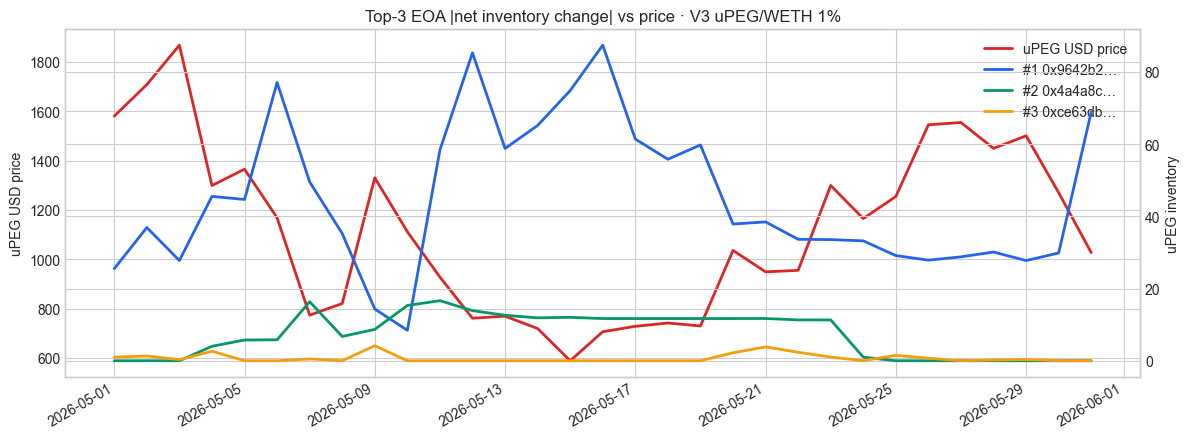

In [37]:
from collections import defaultdict

MAIN_POOL = "0xdc893995d488e5be8ec8ca1db92cbec2a1ab0775"
UPEG_DECIMALS = 18
TOP_N = 3

swaps = json.loads((OUT / "swaps.json").read_text())
transfers = json.loads((OUT / "transfers.json").read_text())
holdings_rows = {
    str(h.get("address") or "").lower(): h
    for h in (json.loads((OUT / "holdings.json").read_text()).get("holdings") or [])
}
exclude = set(pools) | {
    "0x0000000000000000000000000000000000000000",
    "0x000000000004444c5dc75cb358380d2e3de08a90",  # Uniswap V4 PoolManager
}

# Gross transfer flow still used for pair attribution / tie-break.
flow_by_addr = defaultdict(float)
flow_by_addr_pool = defaultdict(lambda: defaultdict(float))
net_by_addr = defaultdict(float)
for t in transfers:
    amt = float(t.get("token0_amount") or 0) / (10 ** UPEG_DECIMALS)
    if amt <= 0:
        continue
    sender = str(t.get("actor") or "").lower()
    recipient = str(t.get("recipient") or "").lower()
    if recipient and recipient not in exclude:
        net_by_addr[recipient] += amt
        flow_by_addr[recipient] += amt
        if sender in pools:
            flow_by_addr_pool[recipient][sender] += amt
    if sender and sender not in exclude:
        net_by_addr[sender] -= amt
        flow_by_addr[sender] += amt
        if recipient in pools:
            flow_by_addr_pool[sender][recipient] += amt

# Fallback pair hint from swaps if an address never touched a verified pool in Transfers.
swap_by_addr_pool = defaultdict(lambda: defaultdict(float))
for s in swaps:
    actor = str(s.get("actor") or "").lower()
    pool = str(s.get("pool_address") or "").lower()
    if not actor or actor in exclude or pool not in pools:
        continue
    swap_by_addr_pool[actor][pool] += float(s.get("amount_usd") or 0)


def is_ranked_eoa(address: str) -> bool:
    h = holdings_rows.get(address) or {}
    if not h:
        return False
    if h.get("is_pool") or h.get("is_contract"):
        return False
    # zero_fill means start balance was not actually queried; net inventory then goes
    # wildly negative/positive for pre-window holders and pollutes the ranking.
    src = str(h.get("balance_source") or "")
    if src in ("", "zero_fill"):
        return False
    return True


candidates = []
for addr, gross in flow_by_addr.items():
    if not is_ranked_eoa(addr):
        continue
    h = holdings_rows[addr]
    start = float(h.get("balance_start_decimal") or 0.0)
    if h.get("net_change_decimal") is not None:
        net_change = float(h["net_change_decimal"])
        end = float(h.get("balance_decimal") if h.get("balance_decimal") is not None else start + net_change)
    else:
        net_change = float(net_by_addr.get(addr) or 0.0)
        end = start + net_change
    if abs(net_change) <= 0:
        continue
    candidates.append(
        {
            "address": addr,
            "transfer_flow_upeg": float(gross),
            "net_change_upeg": float(net_change),
            "abs_net_change_upeg": abs(float(net_change)),
            "start_inventory_upeg": start,
            "end_inventory_upeg": end,
            "balance_source": str(h.get("balance_source") or ""),
        }
    )

candidates.sort(
    key=lambda r: (r["abs_net_change_upeg"], r["transfer_flow_upeg"]),
    reverse=True,
)
top_rows = candidates[:TOP_N]
if len(top_rows) < TOP_N:
    raise RuntimeError(f"need {TOP_N} EOA addresses with inventory change, got {len(top_rows)}")

trader_meta = []
for rank, row in enumerate(top_rows, start=1):
    actor = row["address"]
    flow_upeg = row["transfer_flow_upeg"]
    pool_map = flow_by_addr_pool[actor]
    if pool_map:
        primary_pool = max(pool_map, key=pool_map.get)
        pair_basis = "transfer_with_pool"
        pair_share = pool_map[primary_pool] / flow_upeg if flow_upeg else float("nan")
    elif swap_by_addr_pool[actor]:
        primary_pool = max(swap_by_addr_pool[actor], key=swap_by_addr_pool[actor].get)
        pair_basis = "swap_fallback"
        pair_share = float("nan")
    else:
        primary_pool = MAIN_POOL
        pair_basis = "main_pool_default"
        pair_share = float("nan")
    trader_meta.append(
        {
            "rank": rank,
            "address": actor,
            "transfer_flow_upeg": flow_upeg,
            "net_change_upeg": row["net_change_upeg"],
            "abs_net_change_upeg": row["abs_net_change_upeg"],
            "start_inventory_upeg": row["start_inventory_upeg"],
            "end_inventory_upeg": row["end_inventory_upeg"],
            "balance_source": row.get("balance_source"),
            "primary_pool": primary_pool,
            "primary_pool_label": POOL_LABEL.get(primary_pool, primary_pool[:10] + "…"),
            "pair_basis": pair_basis,
            "primary_pool_share": pair_share,
            "is_contract": bool((holdings_rows.get(actor) or {}).get("is_contract")),
        }
    )
trader_df = pd.DataFrame(trader_meta)
display(trader_df)

price_by_pool_day = (
    usable[["pool_address", "day", "price_usd"]]
    .dropna(subset=["price_usd"])
    .drop_duplicates(["pool_address", "day"])
    .assign(pool_address=lambda d: d["pool_address"].str.lower())
)
main_price = (
    main_panel[["day", "price_usd"]]
    .drop_duplicates("day")
    .sort_values("day")
    .reset_index(drop=True)
)
calendar_days = sorted(main_price["day"].tolist())


def daily_inventory(address: str) -> pd.DataFrame:
    start = float((holdings_rows.get(address) or {}).get("balance_start_decimal") or 0.0)
    events = []
    for t in transfers:
        amt = float(t.get("token0_amount") or 0) / (10 ** UPEG_DECIMALS)
        if amt == 0:
            continue
        day = datetime.fromtimestamp(int(t["block_timestamp"]), tz=timezone.utc).strftime("%Y-%m-%d")
        sender = str(t.get("actor") or "").lower()
        recipient = str(t.get("recipient") or "").lower()
        delta = 0.0
        if recipient == address:
            delta += amt
        if sender == address:
            delta -= amt
        if delta:
            events.append(
                {
                    "day": day,
                    "delta": delta,
                    "ts": int(t["block_timestamp"]),
                    "log_index": int(t.get("log_index") or 0),
                }
            )
    days = sorted(set(calendar_days).union(e["day"] for e in events))
    inv = pd.DataFrame({"day": days})
    if events:
        flow = (
            pd.DataFrame(events)
            .sort_values(["day", "ts", "log_index"])
            .groupby("day", as_index=False)["delta"]
            .sum()
        )
        inv = inv.merge(flow, on="day", how="left")
    else:
        inv["delta"] = 0.0
    inv["delta"] = inv["delta"].fillna(0.0)
    inv["inventory_upeg"] = start + inv["delta"].cumsum()
    return inv[["day", "inventory_upeg"]]


def price_for_pool(pool: str) -> pd.DataFrame:
    sub = price_by_pool_day.loc[price_by_pool_day["pool_address"] == pool, ["day", "price_usd"]]
    if sub.empty:
        return main_price.copy()
    return sub.sort_values("day").reset_index(drop=True)


panels = []
for row in trader_meta:
    inv = daily_inventory(row["address"])
    px = price_for_pool(row["primary_pool"])
    panel = inv.merge(px, on="day", how="left").sort_values("day").reset_index(drop=True)
    panel["address"] = row["address"]
    panel["rank"] = row["rank"]
    panel["primary_pool"] = row["primary_pool"]
    panel["primary_pool_label"] = row["primary_pool_label"]
    panels.append(panel)

same_pair = len({r["primary_pool"] for r in trader_meta}) == 1


def plot_inventory_vs_price(panel: pd.DataFrame, title: str, inventory_cols: dict):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax2 = ax.twinx()
    dates = pd.to_datetime(panel["day"])
    ax.plot(dates, panel["price_usd"], color="#dc2626", linewidth=2, label="uPEG USD price")
    colors = ["#2563eb", "#059669", "#f59e0b"]
    for i, (label, series) in enumerate(inventory_cols.items()):
        ax2.plot(dates, series, color=colors[i % len(colors)], linewidth=2, label=label)
    ax.set_ylabel("uPEG USD price")
    ax2.set_ylabel("uPEG inventory")
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="best")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


if same_pair:
    # Full calendar + ffill so sparse activity days don't drop inventory lines.
    base = main_price[["day", "price_usd"]].copy()
    inv_map = {}
    for p, meta in zip(panels, trader_meta):
        col = f"#{meta['rank']} {meta['address'][:8]}…"
        merged = base[["day"]].merge(p[["day", "inventory_upeg"]], on="day", how="left")
        start = float(meta["start_inventory_upeg"])
        base[col] = merged["inventory_upeg"].ffill().fillna(start)
        inv_map[col] = base[col]
    print(
        "same primary pair:",
        trader_meta[0]["primary_pool_label"],
        trader_meta[0]["primary_pool"],
    )
    display(base.head())
    plot_inventory_vs_price(
        base,
        f"Top-{TOP_N} EOA |net inventory change| vs price · {trader_meta[0]['primary_pool_label']}",
        inv_map,
    )
else:
    print("primary pairs differ → one chart per address")
    for p, meta in zip(panels, trader_meta):
        print(
            f"#{meta['rank']}",
            meta["address"],
            "abs_net_change_upeg",
            round(meta["abs_net_change_upeg"], 4),
            "net_change_upeg",
            round(meta["net_change_upeg"], 4),
            "pair",
            meta["primary_pool_label"],
            "end inventory",
            round(float(p["inventory_upeg"].iloc[-1]), 6),
        )
        display(p.head())
        plot_inventory_vs_price(
            p,
            f"#{meta['rank']} {meta['address'][:10]}… · {meta['primary_pool_label']}",
            {f"inventory {meta['address'][:8]}…": p["inventory_upeg"]},
        )
